In [1]:
import kagglehub

In [2]:
# path = kagglehub.dataset_download('nirmalsankalana/plant-diseases-training-dataset')

In [3]:
path = '/kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset'

In [4]:
import os
import pandas as pd
import glob

txt_file = glob.glob(f"{path}/**/*.txt", recursive=True)

txt_file

KeyboardInterrupt: 

In [ ]:
pd.read_csv(txt_file[0], sep='\t')

In [ ]:
with open(txt_file[0], 'r') as f:
    text = f.read()
    print(text)

In [53]:
from torchvision import datasets, transforms

# transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

dataset = datasets.ImageFolder(f'{path}/data')

In [54]:
class_names, num_classes = dataset.classes, len(dataset.classes)

In [55]:
len(dataset)

116147

In [56]:
train_size = int(0.8*len(dataset))
test_size = len(dataset) - train_size

In [57]:
train_size + test_size == len(dataset)

True

In [58]:
import torch
from torch.utils.data import random_split

torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_data, test_data = random_split(dataset, [train_size, test_size])

<PIL.Image.Image image mode=RGB size=384x256 at 0x7921F2E1BAD0> Apple___healthy
<PIL.Image.Image image mode=RGB size=256x256 at 0x7921F2339640> Potato___early_blight


Text(0.5, 1.0, 'Potato___early_blight')

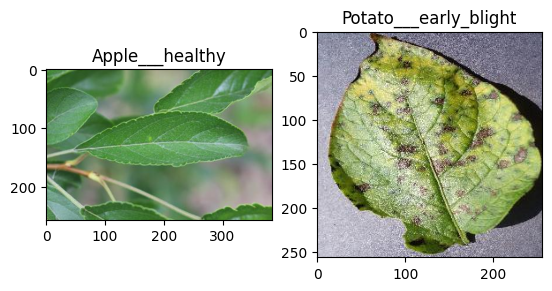

In [59]:
import matplotlib.pyplot as plt
X, y = train_data[0]
print(X, class_names[y])
plt.subplot(1,2,1)
plt.imshow(X)
plt.title(class_names[y])

X, y = test_data[0]
print(X, class_names[y])
plt.subplot(1,2,2)
plt.imshow(X)
plt.title(class_names[y])

In [60]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [61]:
from torch.utils.data import Dataset

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [62]:
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_data = TransformedSubset(train_data, train_transform)
test_data = TransformedSubset(test_data, test_transform)

In [63]:
train_data_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=False)
test_data_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2, pin_memory=False)

In [18]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

In [19]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 215MB/s] 


In [20]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [21]:
from torch import nn
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

In [44]:
model.classifier[2]

Linear(in_features=768, out_features=72, bias=True)

In [46]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier[2].parameters():
    param.requires_grad = True

In [48]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [25]:
#Custom Accuracy Function
def accuracy_fn(y_pred, y_test):
  correct = torch.eq(y_pred, y_test).sum().item()
  acc_score = (correct/len(y_pred))*100
  return acc_score

In [26]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def model_train_loop(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, loss_fn: torch.nn.Module, accuracy_fn, device:torch.device=device):

  train_loss, train_acc = 0, 0

  model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_preds = model(X)

    loss = loss_fn(y_preds, y)
    train_loss += loss.item()

    train_acc += accuracy_fn(y_preds.argmax(dim=1), y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}")


In [27]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def model_test_loop(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device:torch.device=device):

  test_loss, test_acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for (X, y) in data_loader:
      X, y = X.to(device), y.to(device)
      test_preds = model(X)

      loss = loss_fn(test_preds, y)
      test_loss += loss.item()

      test_acc += accuracy_fn(test_preds.argmax(dim=1), y)

  test_loss /= len(data_loader)
  test_acc /= len(data_loader)

  print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}")

In [28]:
#Timer Function
from timeit import default_timer as timer
def print_train_time(start: float, end:float, device:torch.device=None):
  total_time = end-start
  print(f"Train time on {device} : {total_time:.3f} seconds")
  return total_time

In [29]:
from tqdm.auto import tqdm

In [64]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

Epochs = 5

model.to(device)

start_train_test_time = timer()
for epoch in tqdm(range(Epochs)):
    print(f'Epochs {epoch}/{Epochs}\n-------')
    model_train_loop(model, train_data_loader, optimizer, loss_fn, accuracy_fn, device)
    model_test_loop(model, test_data_loader, loss_fn, accuracy_fn, device)
end_train_test_time = timer()
print_train_time(start=start_train_test_time, end=end_train_test_time, device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epochs 0/5
-------
Train Loss: 0.2257 | Train Accuracy: 92.85
Test Loss: 0.2002 | Test Accuracy: 93.27
Epochs 1/5
-------
Train Loss: 0.1951 | Train Accuracy: 93.55
Test Loss: 0.1864 | Test Accuracy: 93.37
Epochs 2/5
-------
Train Loss: 0.1788 | Train Accuracy: 93.93
Test Loss: 0.1763 | Test Accuracy: 93.83
Epochs 3/5
-------
Train Loss: 0.1678 | Train Accuracy: 94.24
Test Loss: 0.1717 | Test Accuracy: 94.09
Epochs 4/5
-------
Train Loss: 0.1604 | Train Accuracy: 94.42
Test Loss: 0.1703 | Test Accuracy: 94.03
Train time on cuda : 2755.040 seconds


2755.0397421879998

In [65]:
torch.save(model, "/kaggle/working/plant_pre_trained_model.pth")

In [ ]:
from IPython.display import display, HTML
import base64

path = "/kaggle/working/plant_pre_trained_model.pth"

with open(path, "rb") as f:
    data = f.read()

b64 = base64.b64encode(data).decode()

display(HTML(f'''
<a download="fashion_cnn_model.pth"
   href="data:application/octet-stream;base64,{b64}">
   <button>Download Model</button>
</a>
'''))